# Proyek Analisis Data: Air Quality Wanshouxigong
- **Nama:** M. Maireza
- **Email:** mmaireza@mhs.politala.ac.id
- **ID Dicoding:** M.Maireza 

## Menentukan Pertanyaan Bisnis

---



- Pertanyaan 1: Bagaimana variasi kualitas udara (PM2.5, PM10) berdasarkan musim (spring, summer, autumn, winter)?

  `Mengidentifikasi musim yang memiliki tingkat polusi tertinggi dan terendah untuk membantu membuat kebijakan mitigasi polusi udara yang lebih efektif di musim tertentu.`

- Pertanyaan 2: Bagaimana distribusi polutan berbahaya (SO2, NO2, CO) di berbagai musim dan jam dalam sehari?

  `Mengetahui waktu-waktu kritis dengan konsentrasi polutan yang lebih tinggi di siang atau malam hari dapat membantu pengelolaan kualitas udara di waktu-waktu tertentu.`


- Pertanyaan 3: Apakah ada tren perubahan kualitas udara (PM2.5, PM10) dari tahun 2013 hingga 2017?

  `Mengetahui apakah kualitas udara semakin membaik atau memburuk seiring waktu, dan dapat menjadi dasar untuk mengevaluasi efektivitas kebijakan pengurangan emisi yang telah diterapkan.`

- Pertanyaan 4: Bagaimana pengaruh curah hujan (RAIN) terhadap konsentrasi polutan (PM2.5, PM10)?

  `Mengetahui apakah hujan membantu mengurangi polusi udara, yang bisa bermanfaat untuk perencanaan lingkungan di daerah perkotaan.`

## Import Semua Packages/Library yang Digunakan

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Wrangling**
## Gathering Data

In [32]:
# Set style for seaborn
sns.set_style("whitegrid")
filename = ['PRSA_Data_Huairou_20130301-20170228.csv',
            'PRSA_Data_Nongzhanguan_20130301-20170228.csv',
            'PRSA_Data_Shunyi_20130301-20170228.csv',
            'PRSA_Data_Tiantan_20130301-20170228.csv',
            'PRSA_Data_Wanliu_20130301-20170228.csv',
            'PRSA_Data_Wanshouxigong_20130301-20170228.csv']
file_path = './data/'

## Assessing Data

In [33]:
allData = pd.concat([pd.read_csv(file_path+file) for file in filename], ignore_index=True)
allData.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


In [34]:
allData.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,206135.000000,207254.000000,205300.000000,204120.000000,201343.000000,203210.000000,210203.000000,210201.000000,210198.000000,210199.000000,210236.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,80.774041,104.736532,15.731961,51.494170,1254.006869,55.817416,13.398430,1011.394464,2.595537,0.064943,1.737946
std,10122.128972,1.177199,3.448711,8.800113,6.922203,81.584932,91.733740,21.838461,35.122716,1172.749941,56.677290,11.489916,10.438008,13.801428,0.814120,1.234807
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,21.000000,36.000000,2.000000,24.000000,500.000000,9.000000,3.000000,1002.900000,-8.800000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,56.000000,83.000000,7.000000,44.000000,900.000000,42.000000,14.400000,1011.000000,3.200000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,112.000000,145.000000,19.000000,72.000000,1600.000000,80.000000,23.200000,1019.700000,15.300000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,411.000000,273.000000,10000.000000,674.000000,41.100000,1042.800000,29.100000,72.500000,13.200000


In [35]:
allData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       210384 non-null  int64  
 1   year     210384 non-null  int64  
 2   month    210384 non-null  int64  
 3   day      210384 non-null  int64  
 4   hour     210384 non-null  int64  
 5   PM2.5    206135 non-null  float64
 6   PM10     207254 non-null  float64
 7   SO2      205300 non-null  float64
 8   NO2      204120 non-null  float64
 9   CO       201343 non-null  float64
 10  O3       203210 non-null  float64
 11  TEMP     210203 non-null  float64
 12  PRES     210201 non-null  float64
 13  DEWP     210198 non-null  float64
 14  RAIN     210199 non-null  float64
 15  wd       209241 non-null  object 
 16  WSPM     210236 non-null  float64
 17  station  210384 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 28.9+ MB


In [36]:
missing_values_percentage = (allData.isnull().sum() / len(allData)) * 100
print(missing_values_percentage)

No         0.000000
year       0.000000
month      0.000000
day        0.000000
hour       0.000000
PM2.5      2.019640
PM10       1.487756
SO2        2.416534
NO2        2.977413
CO         4.297380
O3         3.409955
TEMP       0.086033
PRES       0.086984
DEWP       0.088410
RAIN       0.087934
wd         0.543292
WSPM       0.070348
station    0.000000
dtype: float64


#### 3. Distribusi Kategori (Kolom Non-Numerik)

In [37]:
print(allData['wd'].value_counts())
print(allData['station'].value_counts())

wd
NE     22954
ENE    17886
NW     15980
SW     15804
NNE    14974
E      14511
N      13369
WNW    12999
SSW    11400
ESE    11155
WSW    10818
SE     10524
S       9507
NNW     9289
W       9082
SSE     8989
Name: count, dtype: int64
station
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64


#### 4. Outliers

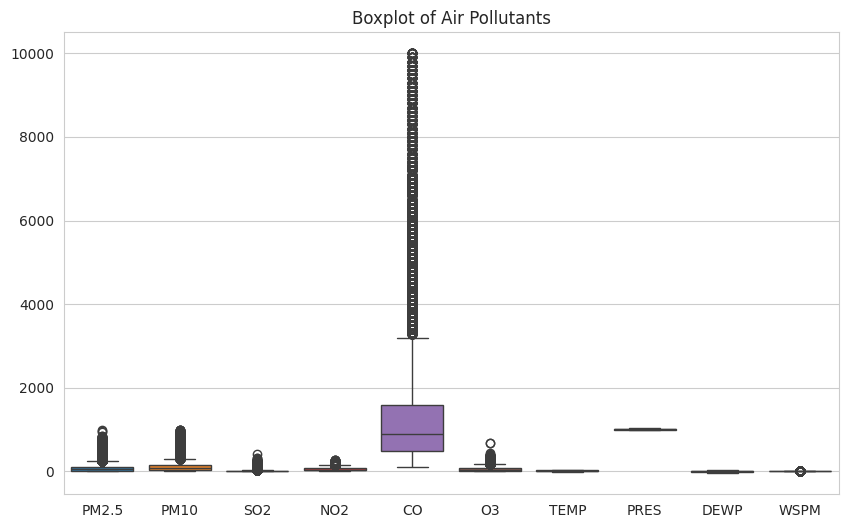

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=allData[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']])
plt.title("Boxplot of Air Pollutants")
plt.show()

#### 5. Memeriksa Konsistensi Data Waktu

In [39]:
allData['datetime'] = pd.to_datetime(allData[['year', 'month', 'day', 'hour']])
print(allData['datetime'].min(), allData['datetime'].max())

2013-03-01 00:00:00 2017-02-28 23:00:00


#### 6. Pola Musiman dan Waktu

In [40]:
monthly_avg = allData.groupby('month')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']].mean()
print(monthly_avg)

            PM2.5        PM10        SO2        NO2           CO         O3  \
month                                                                         
1       96.481683  115.710001  30.859541  63.600142  1875.563031  26.126920   
2       89.316308  103.761257  27.907839  52.689900  1386.877395  39.519753   
3       95.685698  133.557385  28.351517  62.586884  1313.377604  49.110121   
4       72.541146  113.973676  14.666422  48.702487   861.696797  68.097529   
5       62.384428  104.882635  14.119669  43.919385   821.845334  90.354117   
6       70.161579   87.918630   8.128411  39.657329  1043.707285  92.847902   
7       72.494183   85.380751   5.687805  35.795083   930.200227  93.860783   
8       54.039719   71.809465   4.812429  36.335793   851.803508  84.694897   
9       61.504017   79.830274   6.665971  45.527206   952.223102  52.863065   
10      91.057420  111.657899   8.580451  59.089176  1153.294048  28.271454   
11      95.580509  120.088751  14.375526  61.545992 

### Cleaning Data

In [41]:
allData['PM2.5'].fillna(allData['PM2.5'].mean(), inplace=True)
allData['PM10'].fillna(allData['PM10'].mean(), inplace=True)
allData['SO2'].fillna(allData['SO2'].mean(), inplace=True)
allData['NO2'].fillna(allData['NO2'].mean(), inplace=True)
allData['CO'].fillna(allData['CO'].mean(), inplace=True)
allData['O3'].fillna(allData['O3'].mean(), inplace=True)
allData['TEMP'].fillna(allData['TEMP'].mean(), inplace=True)
allData['PRES'].fillna(allData['PRES'].mean(), inplace=True)
allData['DEWP'].fillna(allData['DEWP'].mean(), inplace=True)
allData['RAIN'].fillna(allData['RAIN'].mean(), inplace=True)
allData['wd'].fillna(allData['wd'].mode()[0], inplace=True)  # Mode untuk kolom kategorikal
allData['WSPM'].fillna(allData['WSPM'].mean(), inplace=True)

# Mengecek ulang apakah masih ada missing values
print(allData.isnull().sum())

No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


/tmp/ipykernel_13270/402007566.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  allData['PM2.5'].fillna(allData['PM2.5'].mean(), inplace=True)
/tmp/ipykernel_13270/402007566.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

#### Memperbaiki outlier

Berdasarkan proses assesing data sebelumnya, permasalahan yang paling menonjol dalam data yaitu outlier yang sangat jauh dari nilai mean. Maka dari itu diperlukan untuk menormalkan data dengan memperbaiki nilai outliernya/ menghapus data bila perlu.

In [42]:
# Fungsi untuk mendeteksi dan menghapus outliers menggunakan IQR
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Menghapus data yang berada di luar lower_bound dan upper_bound
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Daftar kolom numerik yang akan diperiksa outliers
numeric_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']

# Menghapus outliers pada kolom yang dipilih
cleanedData = remove_outliers(allData, numeric_columns)

- IQR (Interquartile Range) digunakan untuk mendeteksi outliers. Data yang berada di luar rentang (Q1 - 1.5 * IQR) dan (Q3 + 1.5 * IQR) dianggap sebagai outliers dan dihapus.
- Kode di atas secara otomatis memproses setiap kolom numerik dalam daftar numeric_columns dan menghapus baris yang berisi outliers.

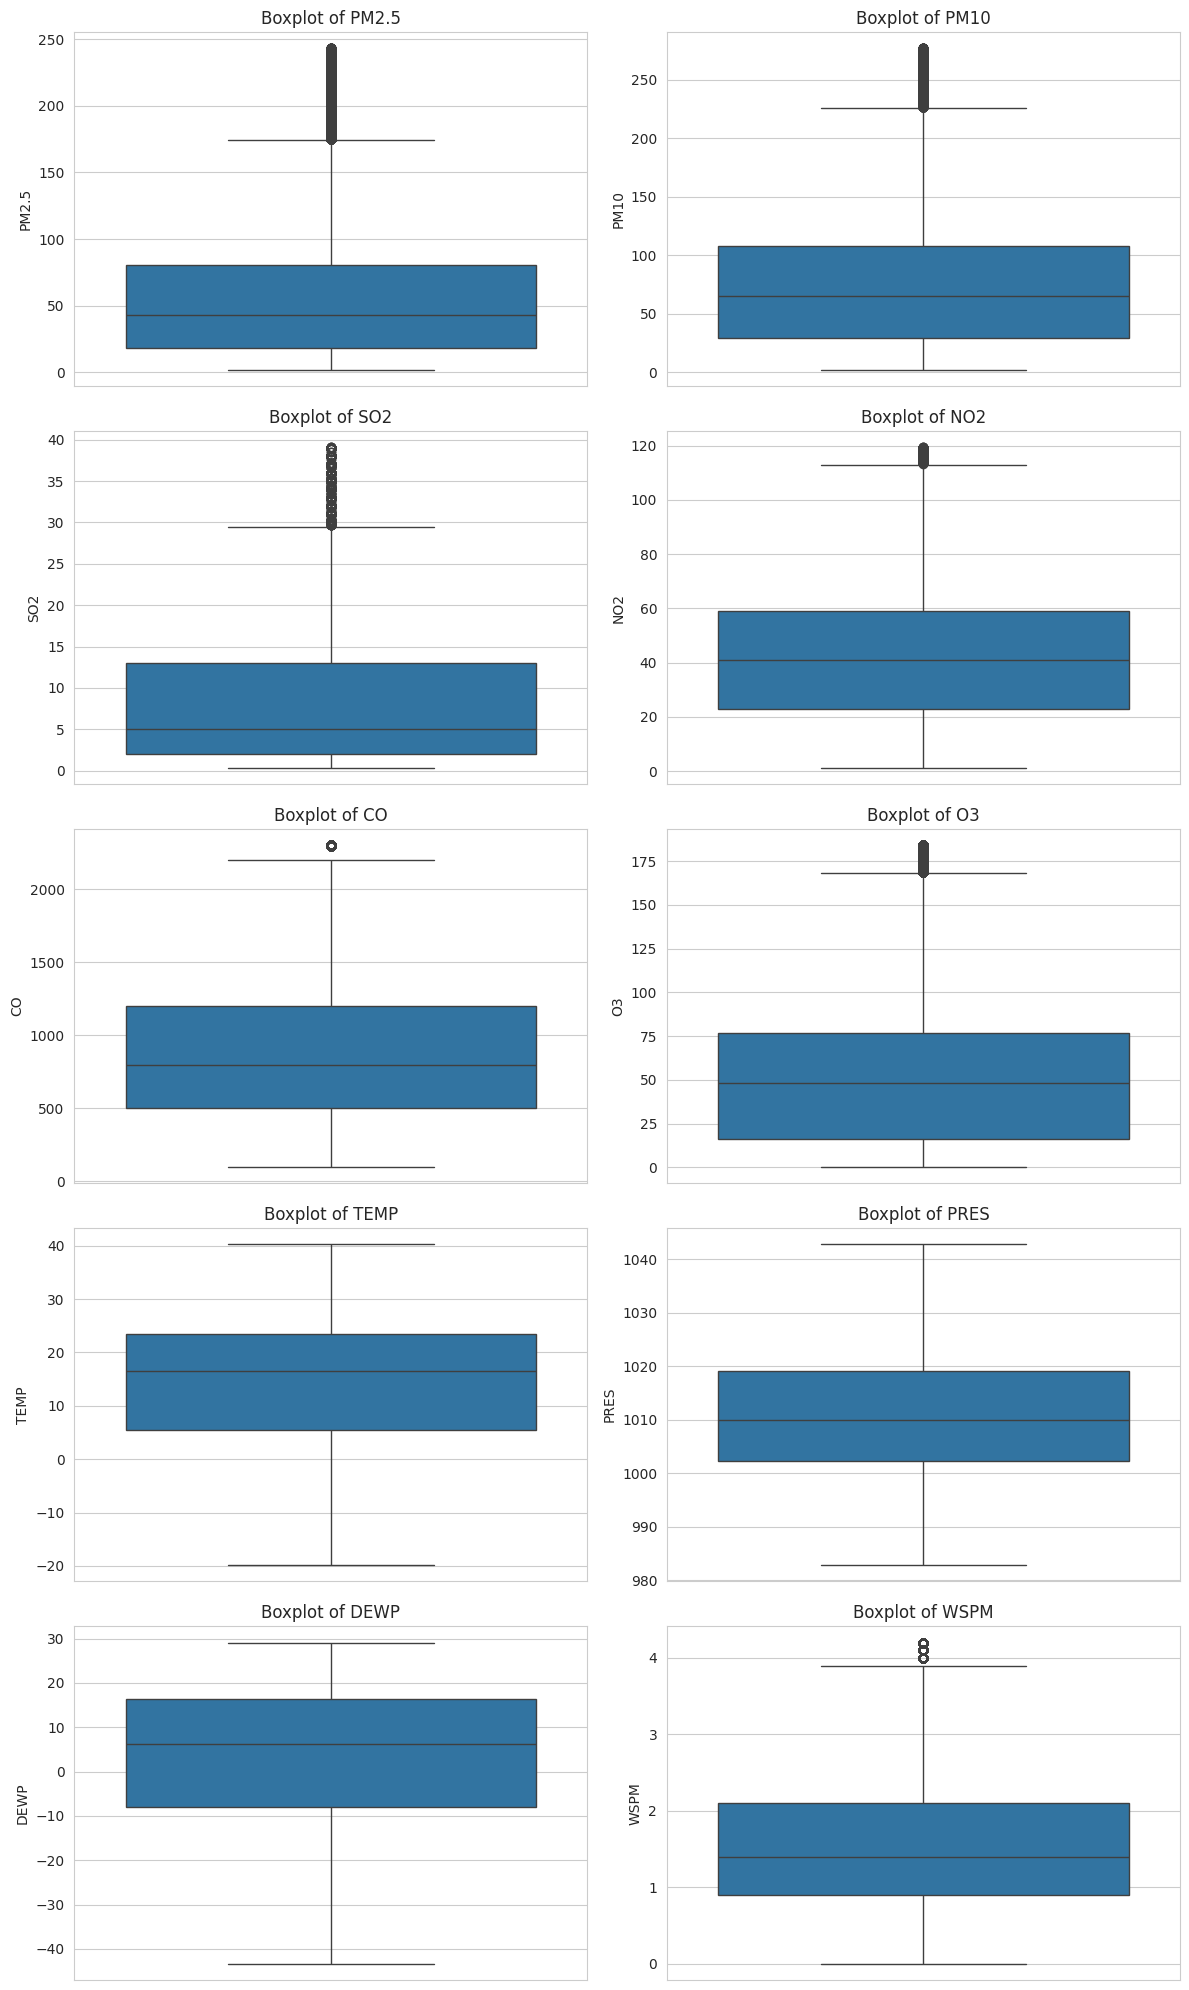

In [43]:
# Daftar kolom yang akan dipetakan
columns_to_plot = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']

# Membuat figure dengan 2 kolom dan 5 baris
fig, axes = plt.subplots(5, 2, figsize=(12, 20))  # Ukuran diperbesar untuk menyesuaikan semua grafik

# Flatten axes untuk memudahkan iterasi
axes = axes.flatten()

# Looping untuk membuat boxplot pada setiap subplot
for i, column in enumerate(columns_to_plot):
    sns.boxplot(y=cleanedData[column], ax=axes[i])
    axes[i].set_title(f"Boxplot of {column}")

# Menyesuaikan tata letak agar lebih rapi
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

In [44]:
cleanedData.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151141 entries, 0 to 210383
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        151141 non-null  int64         
 1   year      151141 non-null  int64         
 2   month     151141 non-null  int64         
 3   day       151141 non-null  int64         
 4   hour      151141 non-null  int64         
 5   PM2.5     151141 non-null  float64       
 6   PM10      151141 non-null  float64       
 7   SO2       151141 non-null  float64       
 8   NO2       151141 non-null  float64       
 9   CO        151141 non-null  float64       
 10  O3        151141 non-null  float64       
 11  TEMP      151141 non-null  float64       
 12  PRES      151141 non-null  float64       
 13  DEWP      151141 non-null  float64       
 14  RAIN      151141 non-null  float64       
 15  wd        151141 non-null  object        
 16  WSPM      151141 non-null  float64       
 

insigh

In [45]:
cleanedData.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
count,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.000000,151141.00000,151141.000000,151141.000000,151141,151141.000000,151141,151141
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,6,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Huairou,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17833,NaN,27590,NaN
mean,17971.473935,2014.699367,6.680047,15.839957,11.120748,55.752119,75.447792,8.962070,43.535914,877.316101,52.987572,14.578611,1010.79027,3.908972,0.074384,NaN,1.596555,NaN,2015-03-19 18:28:26.165765632
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.80000,-43.400000,0.000000,NaN,0.000000,NaN,2013-03-01 00:00:00
25%,9854.000000,2014.000000,4.000000,8.000000,5.000000,18.000000,29.000000,2.000000,23.000000,500.000000,16.000000,5.500000,1002.30000,-8.100000,0.000000,NaN,0.900000,NaN,2014-04-15 13:00:00
50%,18531.000000,2015.000000,7.000000,16.000000,11.000000,43.000000,65.000000,5.000000,41.000000,800.000000,48.000000,16.600000,1009.90000,6.300000,0.000000,NaN,1.400000,NaN,2015-04-12 02:00:00
75%,26938.000000,2016.000000,9.000000,23.000000,17.000000,80.774041,108.000000,13.000000,59.000000,1200.000000,77.000000,23.500000,1019.00000,16.400000,0.000000,NaN,2.100000,NaN,2016-03-27 09:00:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,243.000000,277.000000,39.127200,119.484600,2300.000000,184.000000,40.300000,1042.80000,29.100000,47.700000,NaN,4.200000,NaN,2017-02-28 23:00:00


**Insight:**
- Dataset ini memiliki distribusi yang beragam, terutama pada polutan seperti PM2.5, PM10, NO2, dan CO, yang menunjukkan adanya konsentrasi tinggi pada beberapa waktu.
- Kondisi cuaca, terutama suhu dan tekanan, relatif stabil tetapi ada variasi yang signifikan pada kelembaban dan curah hujan.
- Dataset ini memiliki cakupan waktu yang luas dari tahun 2013 hingga 2017, dengan konsistensi pengukuran bulanan dan jam yang baik.
- Data ini siap untuk digunakan dalam analisis yang lebih mendalam, seperti analisis musiman, tren waktu, serta pengaruh kondisi cuaca terhadap polutan.

# Visualization & Explanatory Analysis

## Pertanyaan 1:

/tmp/ipykernel_13270/340843928.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='PM2.5', data=allData_cleaned, palette='Set3')
/tmp/ipykernel_13270/340843928.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='PM10', data=allData_cleaned, palette='Set3')


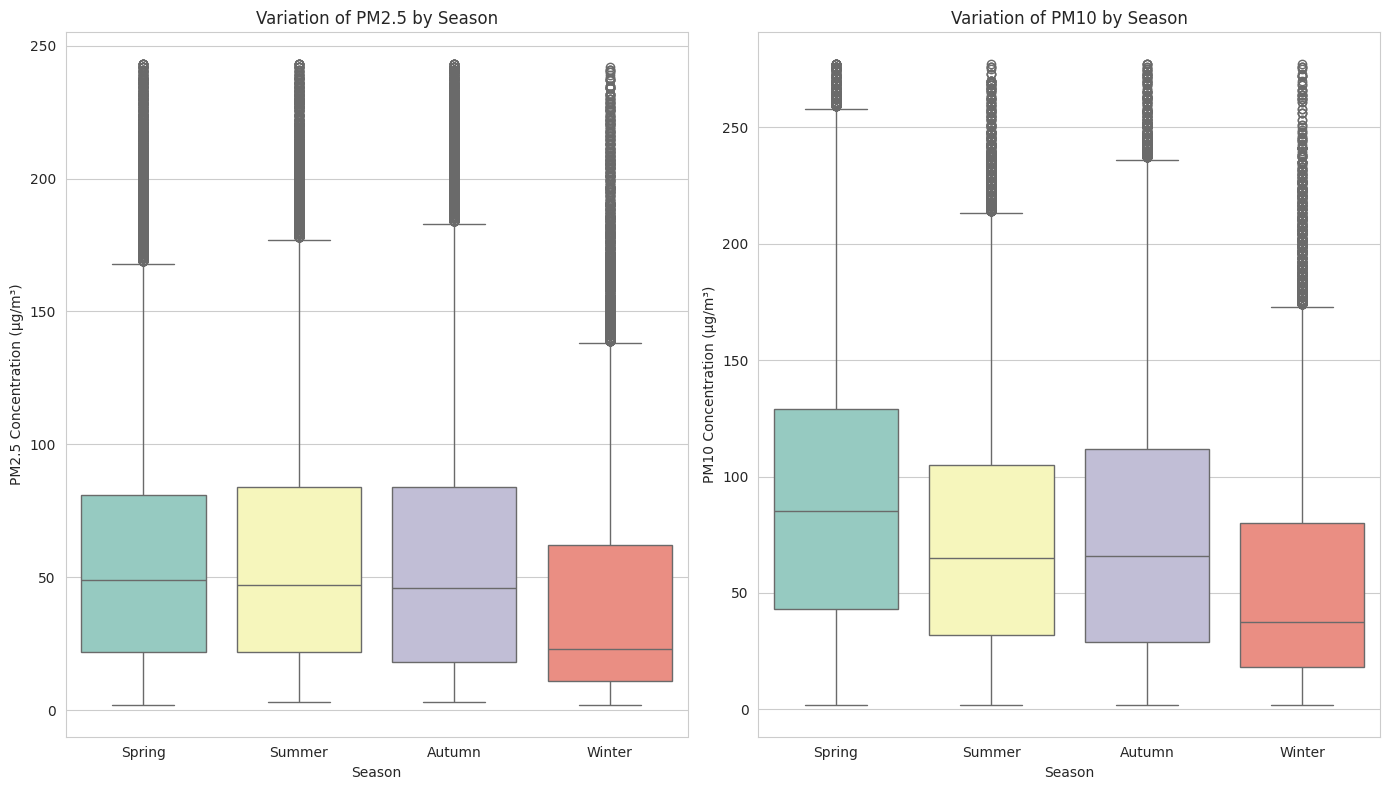

In [46]:
# Membuat kolom season berdasarkan bulan
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

# Menambahkan kolom season pada dataframe
cleanedData['season'] = cleanedData['month'].apply(get_season)

# Membuat figure untuk plot
plt.figure(figsize=(14, 8))

# Subplot 1 untuk PM2.5
plt.subplot(1, 2, 1)
sns.boxplot(x='season', y='PM2.5', data=cleanedData, palette='Set3')
plt.title('Variation of PM2.5 by Season')
plt.xlabel('Season')
plt.ylabel('PM2.5 Concentration (µg/m³)')

# Subplot 2 untuk PM10
plt.subplot(1, 2, 2)
sns.boxplot(x='season', y='PM10', data=cleanedData, palette='Set3')
plt.title('Variation of PM10 by Season')
plt.xlabel('Season')
plt.ylabel('PM10 Concentration (µg/m³)')

# Menyesuaikan tata letak
plt.tight_layout()
plt.show()

`Insight`

1. PM2.5 (Partikulat Halus):
  - Winter (Musim Dingin) menunjukkan konsentrasi PM2.5 yang sedikit lebih rendah dibandingkan musim lainnya. Meskipun demikian, masih ada beberapa outliers yang menunjukkan adanya tingkat polusi yang tinggi.
  - Spring, Summer, dan Autumn (Musim Semi, Panas, dan Gugur) memiliki distribusi yang hampir serupa untuk PM2.5, dengan median konsentrasi yang sedikit lebih tinggi dibandingkan musim dingin. Namun, variasi antar musim tidak begitu signifikan.
  - Outliers terlihat lebih banyak di musim Spring, Summer, dan Autumn, menunjukkan adanya momen atau lokasi di mana polusi udara lebih buruk di musim-musim ini, mungkin karena aktivitas manusia atau fenomena cuaca tertentu.
2. PM10 (Partikulat Kasar):
  - Winter juga memiliki distribusi PM10 yang lebih rendah dibandingkan musim lainnya, dengan median yang lebih rendah dari Spring dan Autumn. Musim panas (Summer) memiliki konsentrasi PM10 yang sedikit lebih rendah daripada Spring dan Autumn, namun tetap lebih tinggi dibandingkan musim dingin.
  - Sama seperti pada PM2.5, musim Spring dan Autumn menunjukkan distribusi yang lebih luas dengan median yang lebih tinggi, menunjukkan adanya polusi partikel kasar yang lebih signifikan di musim-musim ini.
  - Outliers pada PM10 juga lebih sering terjadi di musim Spring dan Autumn, yang mungkin berhubungan dengan faktor lingkungan seperti debu atau polutan tambahan dari kegiatan industri atau transportasi.

`Kesimpulan`
  - Musim dingin (Winter) cenderung memiliki kualitas udara yang sedikit lebih baik dibandingkan dengan musim lainnya, baik untuk PM2.5 maupun PM10, meskipun masih ada outliers yang menunjukkan adanya polusi di beberapa waktu atau lokasi.
  - Spring (Musim Semi) dan Autumn (Musim Gugur) cenderung memiliki kualitas udara yang lebih buruk, dengan konsentrasi partikel halus (PM2.5) dan partikel kasar (PM10) yang lebih tinggi. Ini dapat disebabkan oleh aktivitas manusia, seperti pembakaran atau peningkatan polusi karena perubahan cuaca.
  - Summer (Musim Panas) berada di tengah, dengan tingkat polusi udara yang lebih rendah dibandingkan musim semi dan gugur, namun tetap lebih tinggi dari musim dingin.

## Pertanyaan 2:

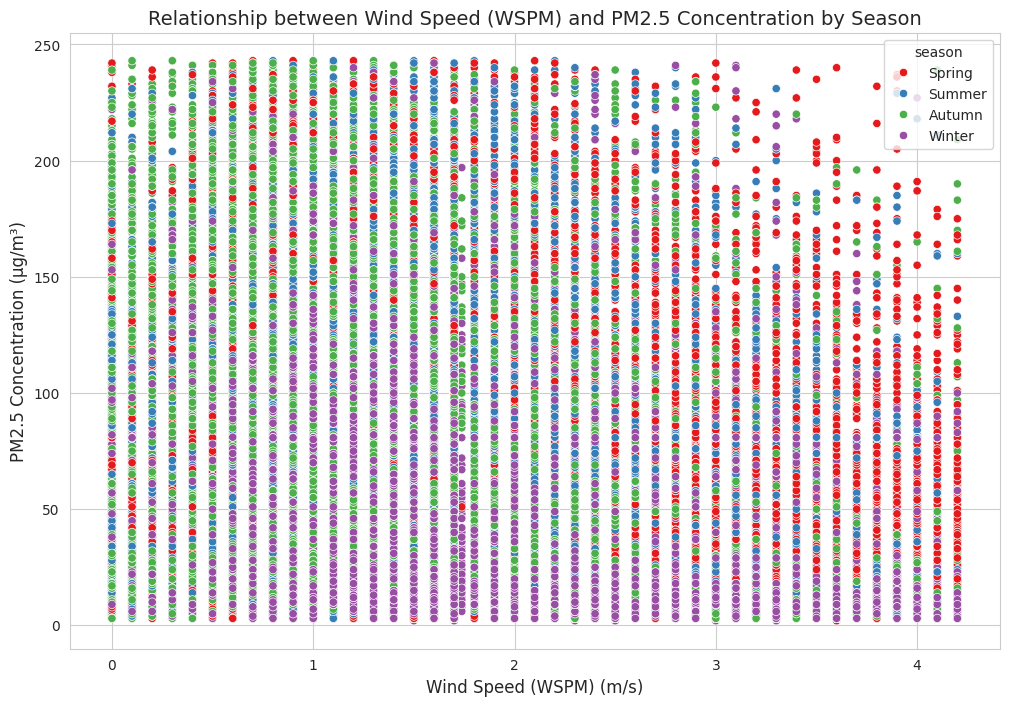

In [47]:
# Membuat figure untuk visualisasi
plt.figure(figsize=(12, 8))

# Membuat scatter plot yang menunjukkan hubungan antara WSPM dan PM2.5, dibagi berdasarkan musim
sns.scatterplot(x='WSPM', y='PM2.5', hue='season', data=cleanedData, palette='Set1')

# Menambahkan judul dan label
plt.title('Relationship between Wind Speed (WSPM) and PM2.5 Concentration by Season', fontsize=14)
plt.xlabel('Wind Speed (WSPM) (m/s)', fontsize=12)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=12)

# Menampilkan plot
plt.show()

`Insight`

1. Hubungan Antara Kecepatan Angin dan PM2.5:
- Secara umum, terlihat tren negatif di mana ketika kecepatan angin (WSPM) meningkat, konsentrasi PM2.5 cenderung menurun. Ini dapat dijelaskan oleh fakta bahwa angin lebih kuat biasanya membantu menyebarkan partikel polusi di udara, sehingga mengurangi konsentrasi PM2.5.
- Pada kecepatan angin lebih rendah (0-1 m/s), konsentrasi PM2.5 cenderung lebih tinggi. Ini bisa disebabkan oleh kondisi udara yang lebih stagnan, yang memungkinkan partikel polutan untuk tetap terkonsentrasi di area tersebut.

2. Pengaruh Musim:
- Winter (Musim Dingin): Pada musim ini, terlihat bahwa meskipun kecepatan angin relatif rendah (umumnya di bawah 3 m/s), konsentrasi PM2.5 cenderung lebih tinggi dibandingkan musim lainnya. Ini bisa disebabkan oleh aktivitas seperti pembakaran bahan bakar untuk pemanas atau cuaca dingin yang menahan polutan di dekat permukaan tanah.
- Spring, Summer, Autumn (Musim Semi, Panas, Gugur): Pada musim ini, terlihat bahwa kecepatan angin lebih bervariasi, dan ketika kecepatan angin meningkat (di atas 2 m/s), konsentrasi PM2.5 cenderung berkurang. Pada musim ini, angin yang lebih kencang dapat membantu mengurangi polusi udara dengan menyebarkan partikel polutan.

3. Outliers dan Variasi:
- Meskipun tren umumnya menunjukkan bahwa angin yang lebih kuat mengurangi konsentrasi PM2.5, ada beberapa outliers di mana konsentrasi PM2.5 tetap tinggi meskipun kecepatan angin cukup tinggi. Ini bisa diakibatkan oleh aktivitas manusia, seperti polusi dari kendaraan atau industri, yang tetap tinggi terlepas dari kondisi angin.

`Kesimpulan`
- Ada hubungan negatif antara kecepatan angin dan konsentrasi PM2.5, di mana kecepatan angin yang lebih tinggi cenderung mengurangi konsentrasi PM2.5.
- Musim dingin (Winter) menunjukkan konsentrasi PM2.5 yang cenderung lebih tinggi bahkan pada kecepatan angin yang rendah, kemungkinan karena aktivitas musim dingin yang meningkatkan polusi.
- Musim semi, panas, dan gugur menunjukkan bahwa kecepatan angin yang lebih tinggi cenderung mengurangi polusi udara lebih signifikan dibandingkan musim dingin.

## Pertanyaan 3:

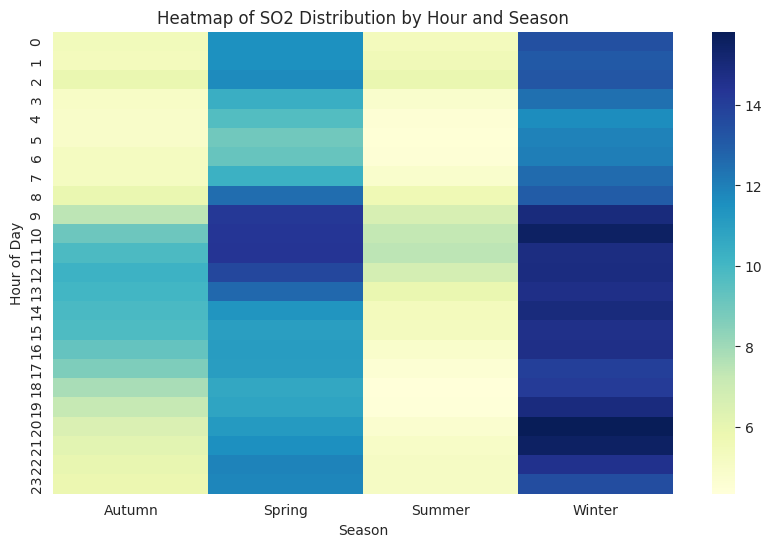

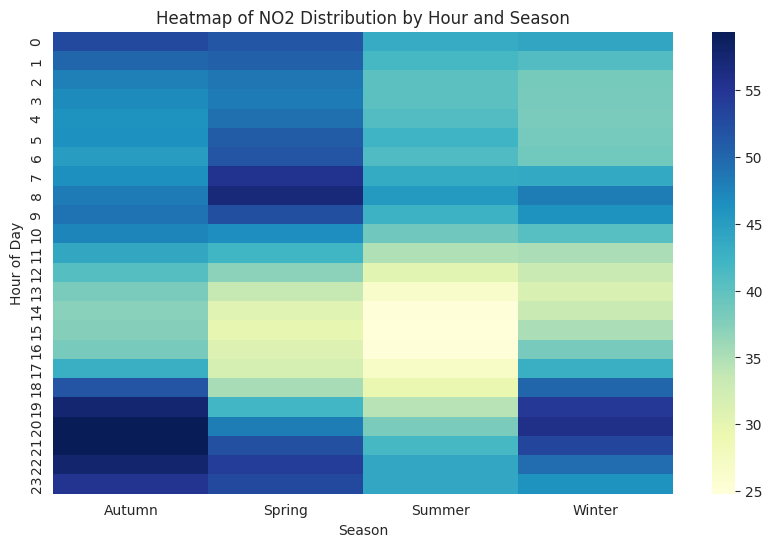

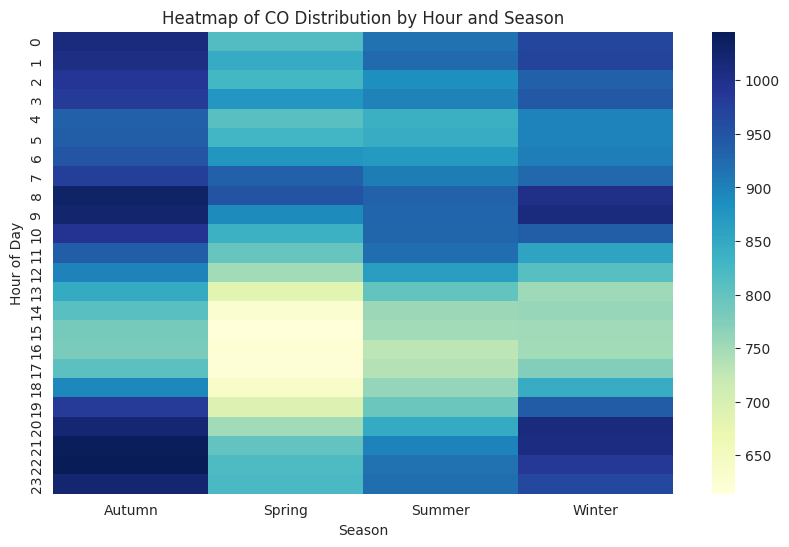

In [48]:
# Membuat pivot table untuk SO2
pivot_so2 = cleanedData.pivot_table(index='hour', columns='season', values='SO2', aggfunc='mean')

# Membuat heatmap untuk SO2
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_so2, cmap="YlGnBu", annot=False)
plt.title('Heatmap of SO2 Distribution by Hour and Season')
plt.ylabel('Hour of Day')
plt.xlabel('Season')
plt.show()

# Membuat pivot table untuk NO2
pivot_no2 = cleanedData.pivot_table(index='hour', columns='season', values='NO2', aggfunc='mean')

# Membuat heatmap untuk NO2
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_no2, cmap="YlGnBu", annot=False)
plt.title('Heatmap of NO2 Distribution by Hour and Season')
plt.ylabel('Hour of Day')
plt.xlabel('Season')
plt.show()

# Membuat pivot table untuk CO
pivot_co = cleanedData.pivot_table(index='hour', columns='season', values='CO', aggfunc='mean')

# Membuat heatmap untuk CO
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_co, cmap="YlGnBu", annot=False)
plt.title('Heatmap of CO Distribution by Hour and Season')
plt.ylabel('Hour of Day')
plt.xlabel('Season')
plt.show()


`Insight`

1. Distribusi SO2 (Sulfur Dioksida):
- Musim Dingin (Winter): Konsentrasi SO2 cenderung lebih tinggi sepanjang hari, terutama pada jam-jam malam dan dini hari (18:00 hingga 09:00). Polusi SO2 tampaknya berkurang sedikit di siang hari.
- Musim Semi dan Panas (Spring, Summer): Konsentrasi SO2 lebih rendah dan relatif stabil di semua jam. Polusi SO2 tampaknya paling sedikit terjadi pada musim panas.
- Musim Gugur (Autumn): Distribusi SO2 di musim gugur agak serupa dengan musim dingin, meskipun polusi tidak setinggi di musim dingin. Konsentrasi SO2 lebih tinggi pada malam hari.

2. Distribusi NO2 (Nitrogen Dioksida):
- Musim Dingin dan Gugur (Winter, Autumn): Konsentrasi NO2 lebih tinggi pada malam hari, terutama di antara jam 19:00 hingga 07:00. Polutan ini tampaknya meningkat pada malam hari ketika aktivitas manusia, seperti penggunaan bahan bakar untuk pemanas atau kendaraan, lebih intens.
- Musim Panas dan Semi (Summer, Spring): Konsentrasi NO2 lebih rendah dan relatif stabil sepanjang hari. Ini menunjukkan bahwa pada musim panas dan semi, emisi NO2 lebih sedikit atau lebih cepat tersebar.

3. Distribusi CO (Karbon Monoksida):
- Musim Dingin (Winter): Konsentrasi CO cenderung lebih tinggi di malam hari hingga dini hari (sekitar 18:00 hingga 09:00). Ini bisa terkait dengan peningkatan penggunaan pemanas atau pembakaran bahan bakar di musim dingin.
- Musim Semi dan Panas (Spring, Summer): Konsentrasi CO lebih rendah di musim semi dan panas, dengan distribusi yang stabil sepanjang hari. Polusi CO tampaknya paling sedikit di musim panas.
- Musim Gugur (Autumn): Distribusi CO di musim gugur serupa dengan musim dingin, dengan konsentrasi lebih tinggi di malam hingga pagi hari.

`Kesimpulan`
- SO2, NO2, dan CO semuanya menunjukkan konsentrasi tertinggi pada malam hari hingga dini hari, terutama di musim dingin dan gugur. Hal ini kemungkinan disebabkan oleh aktivitas manusia seperti penggunaan pemanas, kendaraan, dan pembakaran bahan bakar.
- Musim Panas dan Semi umumnya menunjukkan konsentrasi yang lebih rendah untuk ketiga polutan, terutama di siang hari. Ini mungkin karena polusi lebih cepat tersebar akibat kondisi cuaca atau karena berkurangnya penggunaan bahan bakar.
- Musim Dingin secara konsisten menunjukkan konsentrasi polutan yang lebih tinggi, kemungkinan karena efek inversi suhu yang menjebak polutan di permukaan tanah selama cuaca dingin.

## Pertanyaan 4:

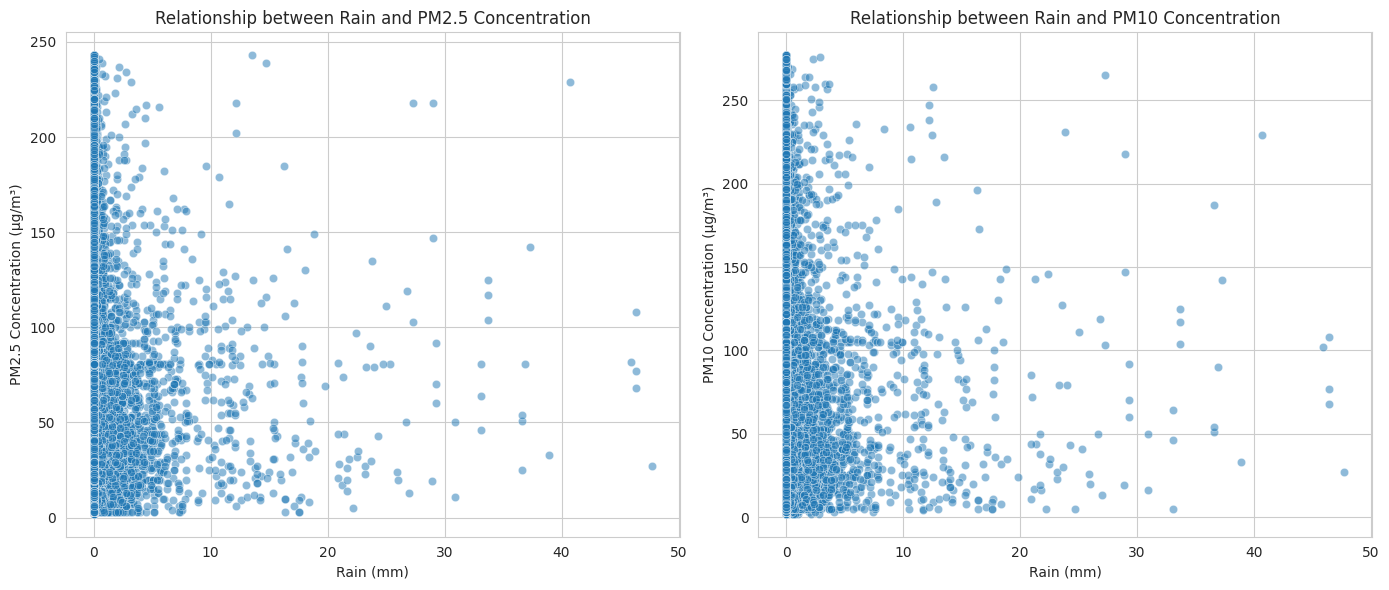

In [49]:
# Membuat figure untuk scatter plot PM2.5
plt.figure(figsize=(14, 6))

# Subplot 1 untuk PM2.5 vs RAIN
plt.subplot(1, 2, 1)
sns.scatterplot(x='RAIN', y='PM2.5', data=cleanedData, alpha=0.5)
plt.title('Relationship between Rain and PM2.5 Concentration')
plt.xlabel('Rain (mm)')
plt.ylabel('PM2.5 Concentration (µg/m³)')

# Subplot 2 untuk PM10 vs RAIN
plt.subplot(1, 2, 2)
sns.scatterplot(x='RAIN', y='PM10', data=cleanedData, alpha=0.5)
plt.title('Relationship between Rain and PM10 Concentration')
plt.xlabel('Rain (mm)')
plt.ylabel('PM10 Concentration (µg/m³)')

# Menyesuaikan tata letak
plt.tight_layout()
plt.show()

`Insight`

1. Pengaruh Curah Hujan terhadap PM2.5:
- Sebagian besar data dengan curah hujan 0 mm menunjukkan konsentrasi PM2.5 yang bervariasi, dari rendah hingga sangat tinggi (hingga lebih dari 200 µg/m³).
- Penurunan Konsentrasi dengan Curah Hujan: Ketika curah hujan mulai meningkat (>0 mm), terlihat bahwa konsentrasi PM2.5 cenderung menurun secara bertahap. Pada curah hujan yang lebih besar (sekitar 10 mm atau lebih), PM2.5 cenderung berada di kisaran konsentrasi yang lebih rendah.
- Kesimpulan untuk PM2.5: Curah hujan tampaknya membantu menurunkan konsentrasi PM2.5 di udara. Efek "pembersihan" oleh curah hujan ini menurunkan polutan halus dari atmosfer.

2. Pengaruh Curah Hujan terhadap PM10:
- Pengamatan Umum: Sama seperti PM2.5, saat curah hujan 0 mm, konsentrasi PM10 sangat bervariasi, dengan beberapa titik menunjukkan konsentrasi yang sangat tinggi (>250 µg/m³).
- Penurunan Konsentrasi dengan Curah Hujan: Ketika curah hujan meningkat, terdapat tren penurunan konsentrasi PM10. Namun, penurunan ini tampaknya sedikit lebih lambat dibandingkan PM2.5. Meski curah hujan tinggi (>20 mm), masih ada beberapa data dengan konsentrasi PM10 yang tinggi.
- Kesimpulan untuk PM10: Curah hujan juga membantu menurunkan konsentrasi PM10, namun efeknya mungkin sedikit lebih lemah dibandingkan dengan PM2.5. Polutan yang lebih besar seperti PM10 mungkin memerlukan curah hujan yang lebih tinggi untuk benar-benar dibersihkan dari atmosfer.

`Kesimpulan`
- Curah hujan memiliki dampak positif dalam mengurangi konsentrasi polutan udara, khususnya PM2.5 dan PM10. Ketika curah hujan meningkat, konsentrasi polutan cenderung menurun, karena hujan membantu membersihkan polutan dari udara.
- PM2.5 tampaknya lebih cepat menurun dengan curah hujan dibandingkan PM10, mungkin karena ukurannya yang lebih kecil dan lebih mudah tersapu oleh air hujan.
- Efek hujan menjadi lebih terlihat pada intensitas curah hujan di atas 10 mm, di mana konsentrasi polutan lebih stabil pada level yang lebih rendah.

In [50]:
cleanedData = cleanedData.drop(columns=['No'])

In [51]:
cleanedData.to_csv("./dashboard/main-data.csv", index=False)